In [1]:
import pandas as pd

In [2]:
#https://machinelearningmastery.com/time-series-forecasting-methods-in-python-cheat-sheet/

In [3]:
from nselib import capital_market as cm

# Define dates as strings in DD-MM-YYYY format
start_date = '01-06-2021'
end_date = '05-01-2022'

# Use the correct function: price_volume_data
stk_data = cm.price_volume_data(symbol='TATACOFFEE', from_date=start_date, to_date=end_date)

print(stk_data.head())

       Symbol Series         Date  PrevClose  OpenPrice  HighPrice  LowPrice  \
0  TATACOFFEE     EQ  05-Jan-2022     217.80     218.50      218.7    214.30   
1  TATACOFFEE     EQ  04-Jan-2022     214.05     214.90      220.8    212.45   
2  TATACOFFEE     EQ  03-Jan-2022     213.15     213.95      216.9    212.30   
3  TATACOFFEE     EQ  31-Dec-2021     208.50     208.90      216.2    208.40   
4  TATACOFFEE     EQ  30-Dec-2021     211.35     211.45      211.5    207.90   

   LastPrice  ClosePrice  AveragePrice TotalTradedQuantity        Turnover₹  \
0     214.65      214.85        215.72           13,50,483  29,13,25,687.40   
1     217.40      217.80        217.41           34,77,443  75,60,37,979.15   
2     214.30      214.05        214.76           15,25,259  32,75,66,528.25   
3     213.70      213.15        213.37           30,45,699  64,98,54,073.20   
4     208.80      208.50        209.36            9,77,484  20,46,47,553.50   

  No.ofTrades  
0      12,079  
1      28,87

In [4]:
stk_data=stk_data[["OpenPrice","HighPrice","LowPrice","ClosePrice"]]

In [5]:
column="ClosePrice"

In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (151, 1)


In [7]:
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(data1, order=i)
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(0, len(data1)-1)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)
    

C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE-Testset: 0.09892903830200285
maPe-Testset: 3018494362964.4014
RMSE-Testset: 0.09930742531540693
maPe-Testset: 2476058117378.3213


C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE-Testset: 0.12462164462102988
maPe-Testset: 690786272365.9019
RMSE-Testset: 0.10312909753658049
maPe-Testset: 2304540879386.299


C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


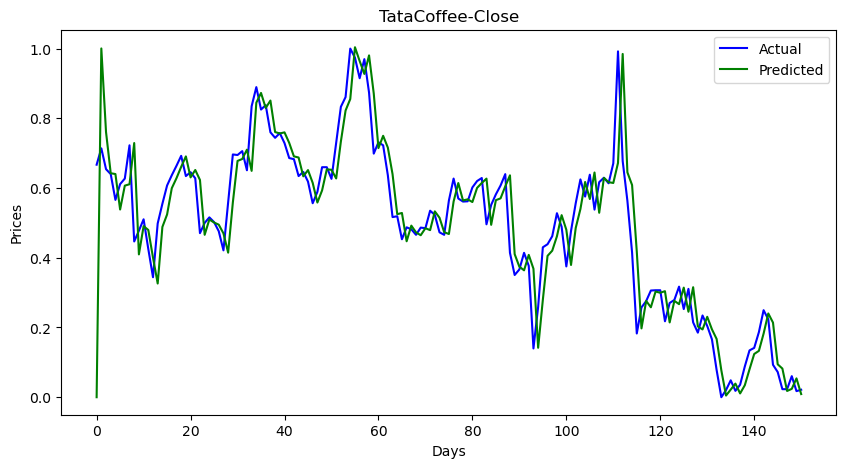

In [8]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [9]:
len(data1)

151

In [10]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [11]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

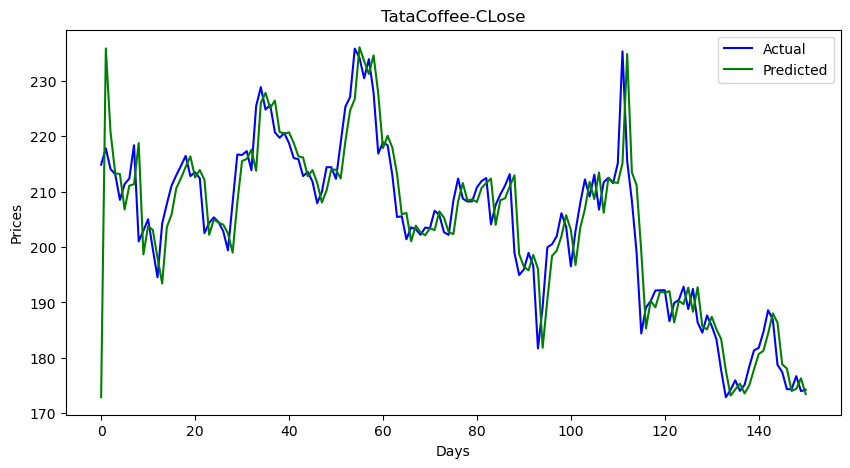

In [12]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [13]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 6.486820235050913
maPe-Testset: 0.02030170876714884


C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [15]:
forecast

array([0.02245673, 0.01586555, 0.0113703 , 0.00729175])

In [16]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closeforge"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [17]:
forecast_stock_price_test_oriF.to_csv("Closet124.csv",index=False)

In [18]:
forecast_stock_price_test_oriF

,Closefore
0,174.312528
1,173.897943
2,173.615192
3,173.358651
